# Convexidade e condicionamento

**Tema:** Álgebra Linear e Otimização › Cálculo e Gradiente Descendente

Este notebook fecha o módulo respondendo duas perguntas: **por que algumas
funções são "fáceis" de otimizar e outras não** (convexidade), e **por que
duas funções igualmente convexas podem exigir números de iteração muito
diferentes** (condicionamento da Hessiana).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(17)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Convexa vs. não-convexa: a definição geométrica, visualmente

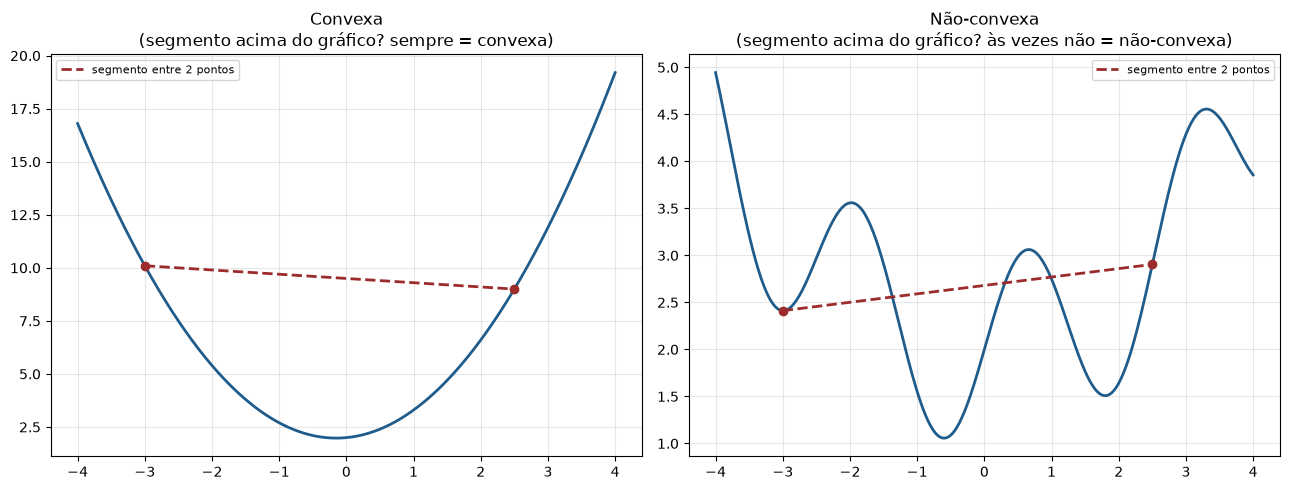

In [2]:
def convexa(x):
    return x**2 + 0.3 * x + 2


def nao_convexa(x):
    return np.sin(2.5 * x) + 0.15 * x**2 + 2


x = np.linspace(-4, 4, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fn, nome in [(axes[0], convexa, "Convexa"), (axes[1], nao_convexa, "Não-convexa")]:
    ax.plot(x, fn(x), color=AZUL, lw=2)
    a, b = -3.0, 2.5
    ax.plot([a, b], [fn(a), fn(b)], color=VERMELHO, lw=2, ls="--",
            label="segmento entre 2 pontos")
    ax.scatter([a, b], [fn(a), fn(b)], color=VERMELHO, zorder=5)
    ax.set_title(f"{nome}\n(segmento acima do gráfico? "
                f"{'sempre = convexa' if nome == 'Convexa' else 'às vezes não = não-convexa'})")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Na função convexa, **qualquer** segmento ligando dois pontos do gráfico fica
acima da curva. Na não-convexa, dependendo dos dois pontos escolhidos, o
segmento pode cruzar por baixo — a marca registrada de não-convexidade.

## 2. O problema prático: onde o gradiente descendente termina depende de onde começa

Numa função não-convexa, otimizar a partir de pontos de partida diferentes
pode levar a mínimos locais diferentes. Numa convexa, não importa de onde
você parte — o destino é sempre o mesmo mínimo global.

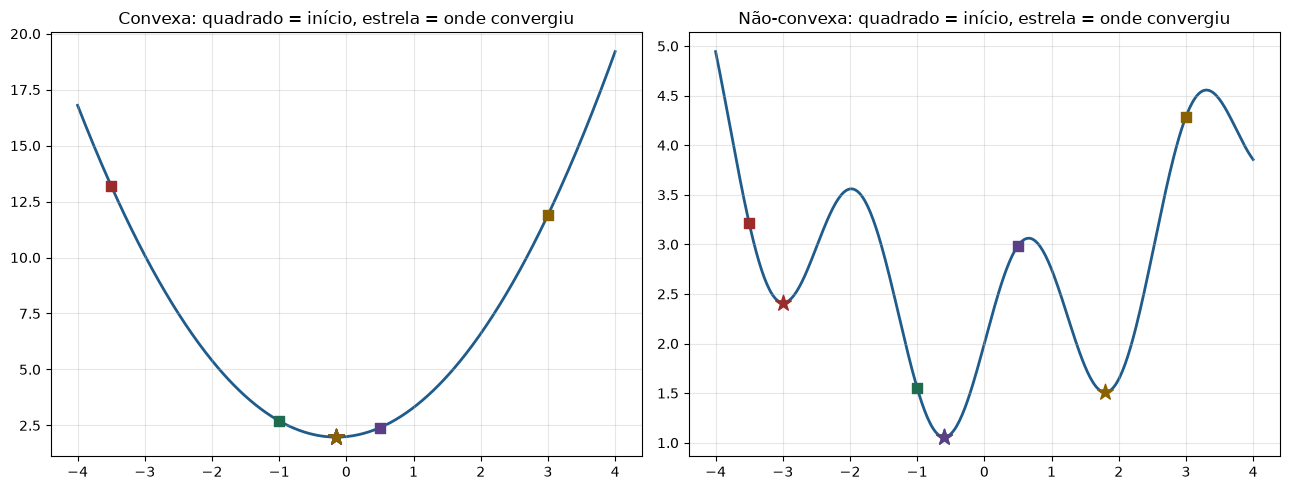

Na função CONVEXA, toda estrela cai no mesmo lugar — o mínimo global.
Na função NÃO-CONVEXA, estrelas diferentes podem parar em vales diferentes.


In [3]:
def grad_convexa(x):
    return 2 * x + 0.3


def grad_nao_convexa(x):
    return 2.5 * np.cos(2.5 * x) + 0.3 * x


def gd_1d(grad_fn, x0, eta, n_iter=200):
    x = x0
    traj = [x]
    for _ in range(n_iter):
        x = x - eta * grad_fn(x)
        traj.append(x)
    return np.array(traj)


pontos_iniciais = [-3.5, -1.0, 0.5, 3.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fn, grad_fn, nome in [(axes[0], convexa, grad_convexa, "Convexa"),
                              (axes[1], nao_convexa, grad_nao_convexa, "Não-convexa")]:
    ax.plot(x, fn(x), color=AZUL, lw=2, zorder=1)
    for x0, cor in zip(pontos_iniciais, [VERMELHO, VERDE, ROXO, AMBAR]):
        traj = gd_1d(grad_fn, x0, eta=0.05)
        ax.scatter([x0], [fn(x0)], color=cor, marker="s", s=50, zorder=5)
        ax.scatter([traj[-1]], [fn(traj[-1])], color=cor, marker="*", s=140, zorder=6)
    ax.set_title(f"{nome}: quadrado = início, estrela = onde convergiu")
plt.tight_layout(); plt.show()

print("Na função CONVEXA, toda estrela cai no mesmo lugar — o mínimo global.")
print("Na função NÃO-CONVEXA, estrelas diferentes podem parar em vales diferentes.")

## 3. A Hessiana em 2D: autovalores decidem mínimo, máximo ou sela

In [4]:
def classifica_ponto_critico(hessiana):
    autoval = np.linalg.eigvalsh(hessiana)
    if np.all(autoval > 0):
        return "mínimo local", autoval
    if np.all(autoval < 0):
        return "máximo local", autoval
    return "ponto de sela", autoval


casos_hessiana = {
    "tigela (mínimo)": np.array([[2.0, 0.0], [0.0, 4.0]]),
    "cúpula (máximo)": np.array([[-3.0, 0.0], [0.0, -1.0]]),
    "sela": np.array([[3.0, 0.0], [0.0, -2.0]]),
}

for nome, H in casos_hessiana.items():
    classe, autoval = classifica_ponto_critico(H)
    print(f"{nome:<18s} autovalores={autoval}   -> {classe}")

tigela (mínimo)    autovalores=[2. 4.]   -> mínimo local
cúpula (máximo)    autovalores=[-3. -1.]   -> máximo local
sela               autovalores=[-2.  3.]   -> ponto de sela


## 4. Visualizando as três formas locais

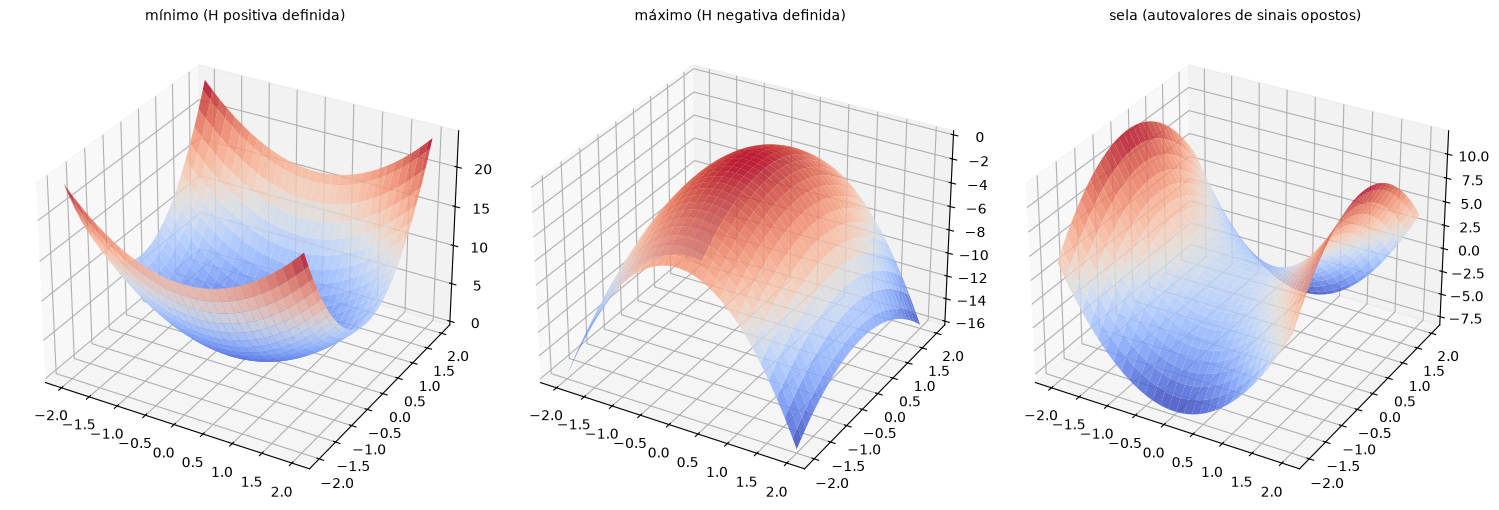

In [5]:
xx, yy = np.meshgrid(np.linspace(-2, 2, 60), np.linspace(-2, 2, 60))
formas = {
    "mínimo (H positiva definida)": 2 * xx**2 + 4 * yy**2,
    "máximo (H negativa definida)": -3 * xx**2 - 1 * yy**2,
    "sela (autovalores de sinais opostos)": 3 * xx**2 - 2 * yy**2,
}

fig = plt.figure(figsize=(15, 5))
for i, (nome, zz) in enumerate(formas.items(), start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    ax.plot_surface(xx, yy, zz, cmap="coolwarm", alpha=0.85)
    ax.set_title(nome, fontsize=10)
plt.tight_layout(); plt.show()

## 5. Número de condição: o vilão da velocidade de convergência

Para $f(x,y) = \frac{1}{2}(a x^2 + b y^2)$, a Hessiana é `diag(a, b)`,
constante em todo lugar. O número de condição é $\max(a,b)/\min(a,b)$.

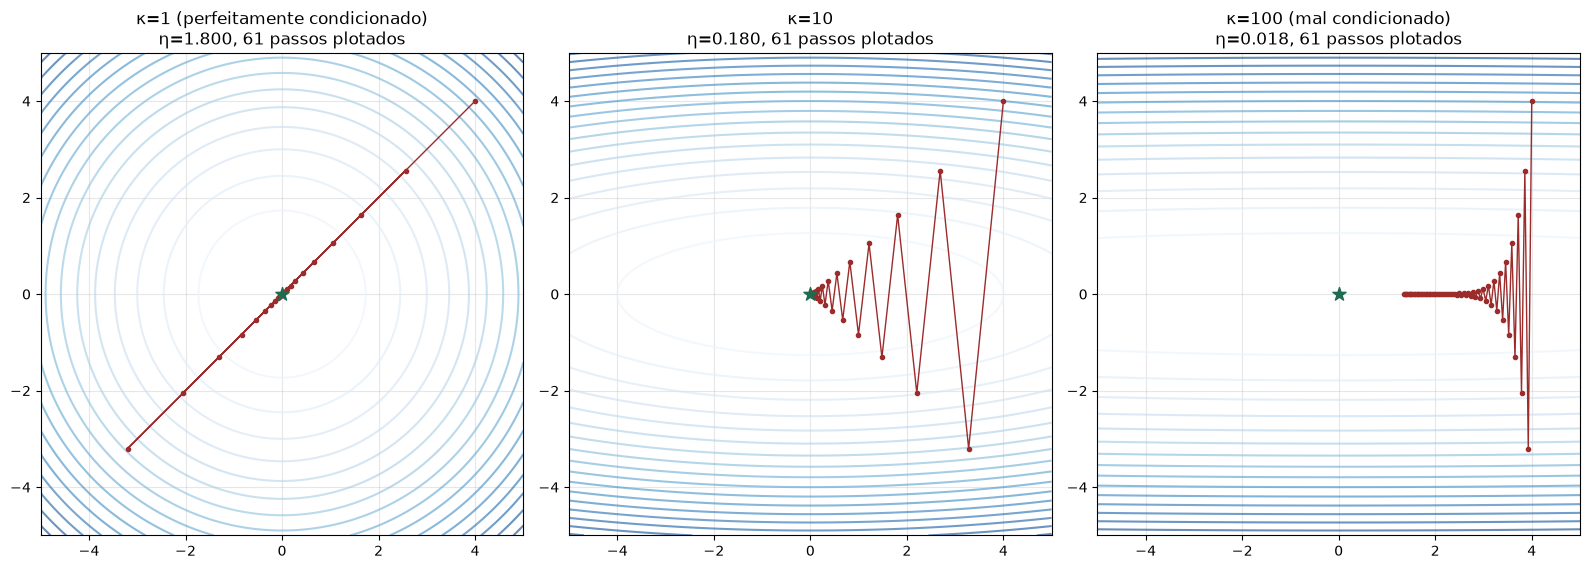

In [6]:
def gd_quadratica(a, b, v0, eta, n_iter):
    v = v0.copy()
    traj = [v.copy()]
    for _ in range(n_iter):
        grad = np.array([a * v[0], b * v[1]])
        v = v - eta * grad
        traj.append(v.copy())
    return np.array(traj)


v0 = np.array([4.0, 4.0])
casos_condicao = [(1.0, 1.0, "κ=1 (perfeitamente condicionado)"),
                  (1.0, 10.0, "κ=10"),
                  (1.0, 100.0, "κ=100 (mal condicionado)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (a, b, nome) in zip(axes, casos_condicao):
    eta_segura = 1.8 / max(a, b)  # taxa perto do limite de estabilidade para o eixo mais íngreme
    traj = gd_quadratica(a, b, v0, eta=eta_segura, n_iter=60)
    xg, yg = np.meshgrid(np.linspace(-5, 5, 150), np.linspace(-5, 5, 150))
    zg = 0.5 * (a * xg**2 + b * yg**2)
    ax.contour(xg, yg, zg, levels=20, cmap="Blues", alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], "o-", color=VERMELHO, ms=3, lw=1)
    ax.scatter([0], [0], color=VERDE, s=100, marker="*", zorder=5)
    ax.set_title(f"{nome}\nη={eta_segura:.3f}, {len(traj)} passos plotados")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 6. Iterações até convergir, em função do número de condição

Vamos medir, para cada $\kappa$, quantas iterações são necessárias para
reduzir a distância ao mínimo por um fator de $10^{-4}$ — usando, em cada
caso, a melhor taxa de aprendizado possível para aquele problema.

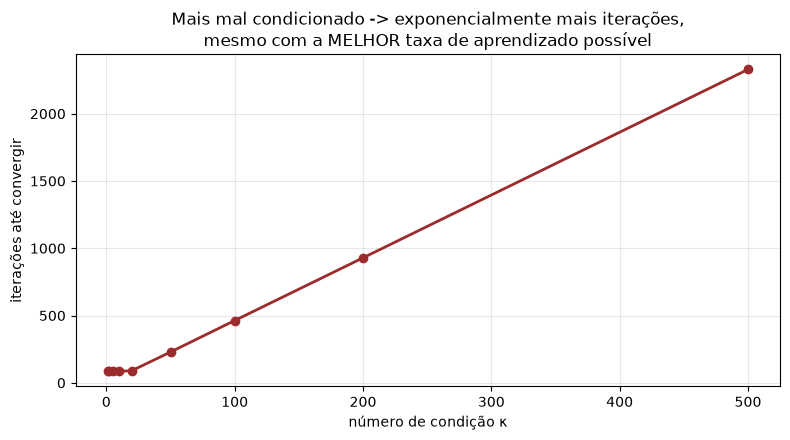

     κ    iterações
     1           88
     2           85
     5           85
    10           85
    20           91
    50          229
   100          463
   200          929
   500         2329


In [7]:
def iteracoes_ate_convergir(a, b, v0, tolerancia=1e-4, max_iter=20000):
    eta = 1.9 / max(a, b)
    v = v0.copy()
    dist0 = np.linalg.norm(v)
    for it in range(1, max_iter + 1):
        grad = np.array([a * v[0], b * v[1]])
        v = v - eta * grad
        if np.linalg.norm(v) / dist0 < tolerancia:
            return it
    return max_iter


condicoes = [1, 2, 5, 10, 20, 50, 100, 200, 500]
iteracoes = [iteracoes_ate_convergir(1.0, k, v0) for k in condicoes]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(condicoes, iteracoes, "o-", color=VERMELHO, lw=2)
ax.set_xlabel("número de condição κ"); ax.set_ylabel("iterações até convergir")
ax.set_title("Mais mal condicionado -> exponencialmente mais iterações,\n"
             "mesmo com a MELHOR taxa de aprendizado possível")
plt.tight_layout(); plt.show()

print(f"{'κ':>6s} {'iterações':>12s}")
for k, it in zip(condicoes, iteracoes):
    print(f"{k:>6d} {it:>12d}")

**A lição central do módulo, em números:** dobrar o número de condição não
dobra o custo — o custo cresce de forma muito mais agressiva. Isso não é uma
falha do algoritmo; é uma propriedade do problema. Nenhuma escolha de $\eta$
escapa dela — só técnicas de pré-condicionamento (padronizar features,
normalizações, Adam) atacam a causa raiz.

## 7. Padronização como pré-condicionamento: efeito em dados reais

In [8]:
n = 400
x1 = rng.normal(50, 15, n)      # escala grande
x2 = rng.normal(0, 0.05, n)     # escala pequena
X_bruto = np.column_stack([x1, x2])
y = 2 * x1 - 300 * x2 + rng.normal(0, 1, n)


def hessiana_mse(X):
    return (2 / len(X)) * X.T @ X


H_bruto = hessiana_mse(X_bruto)
X_padronizado = (X_bruto - X_bruto.mean(0)) / X_bruto.std(0)
H_padronizado = hessiana_mse(X_padronizado)

cond_bruto = np.linalg.cond(H_bruto)
cond_padronizado = np.linalg.cond(H_padronizado)

print(f"número de condição da Hessiana — features BRUTAS     : {cond_bruto:.2e}")
print(f"número de condição da Hessiana — features PADRONIZADAS: {cond_padronizado:.2e}")
print(f"\nrazão de melhora: {cond_bruto / cond_padronizado:.1f}x mais bem condicionado")

número de condição da Hessiana — features BRUTAS     : 1.16e+06
número de condição da Hessiana — features PADRONIZADAS: 1.01e+00

razão de melhora: 1154818.1x mais bem condicionado


**Em palavras:** as duas features do exemplo têm escalas ~1000x diferentes
(idade em dezenas vs. uma proporção pequena). Isso por si só cria um número
de condição altíssimo na Hessiana do problema de mínimos quadrados —
independente de qualquer coisa relacionada ao "sinal" real dos dados.
Padronizar não é só conveniência estatística: é uma correção direta e
poderosa da dificuldade geométrica de otimização.

## O que levar deste notebook

- Convexidade garante que todo mínimo local é global — o destino da
  otimização não depende de onde ela começa.
- Autovalores da Hessiana classificam pontos críticos: todos positivos
  (mínimo), todos negativos (máximo), sinais mistos (sela).
- O número de condição da Hessiana — não apenas a convexidade — determina a
  velocidade de convergência: problemas mal condicionados são lentos mesmo
  com a melhor taxa de aprendizado possível.
- Padronizar features é, na prática, uma técnica de pré-condicionamento: ela
  reduz diretamente o número de condição do problema de otimização, não
  apenas "arruma a escala dos números".

→ Próximo: o notebook de **exercícios** do módulo — e, em seguida, o tema de
Preparação de Dados, onde essas ideias reaparecem na prática de todo dia.